In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [4]:
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [7]:
df = pd.read_csv('/content/train.csv')

In [8]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
df.drop(columns='Id', inplace=True)

<Axes: >

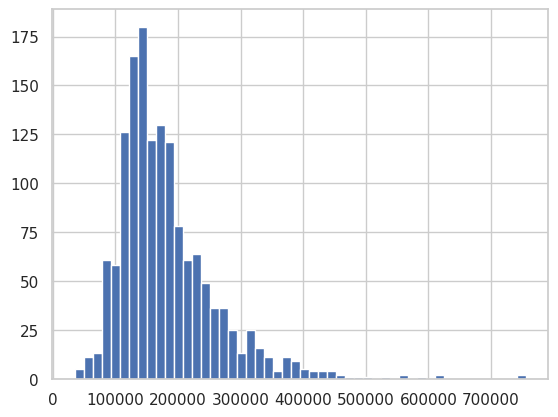

In [11]:
df["SalePrice"].hist(bins=50)

In [12]:
y = np.log1p(df['SalePrice'])
X = df.drop(columns=['SalePrice'])

print(f'Dataset shape: {X.shape}')
print(f'log(SalePrice) = mean: {y.mean():.3f} std: {y.std():.3f}')

Dataset shape: (1460, 79)
log(SalePrice) = mean: 12.024 std: 0.399


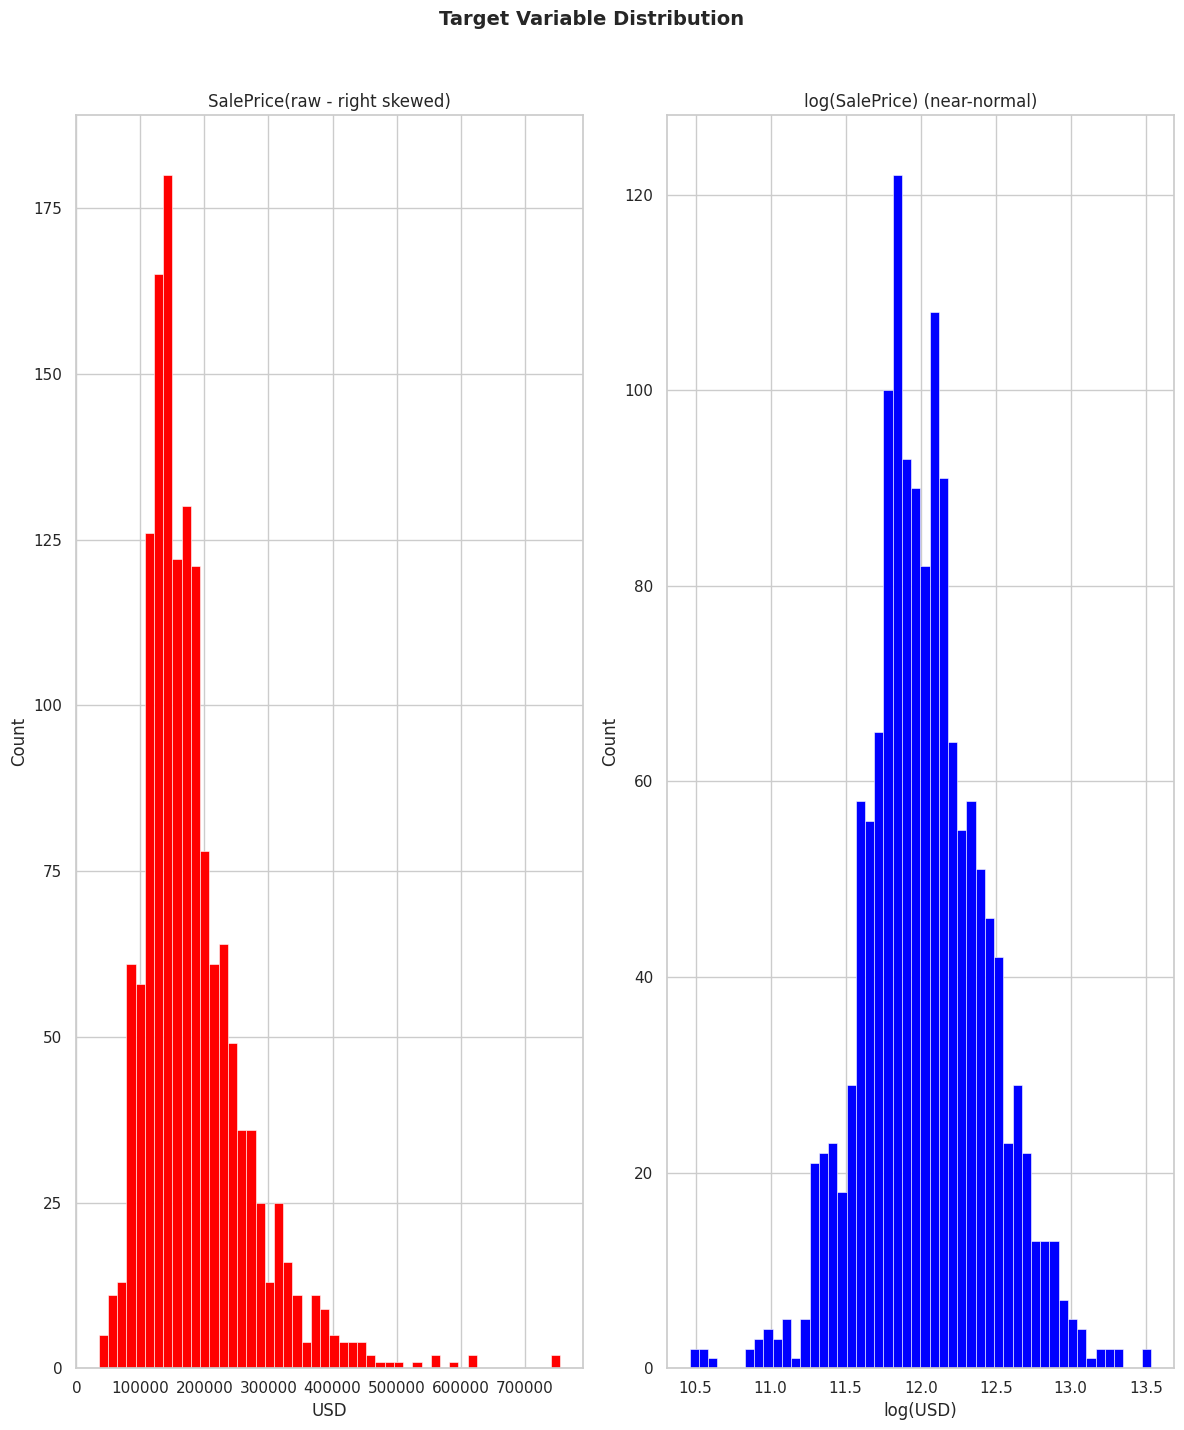

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,14))

axes[0].hist(np.expm1(y), bins=50, color='red', edgecolor='white', linewidth=0.4)
axes[0].set_title('SalePrice(raw - right skewed)', fontsize=12)
axes[0].set_xlabel('USD')
axes[0].set_ylabel('Count')

axes[1].hist(y, bins=50, color='blue', edgecolor='white', linewidth=0.4)
axes[1].set_title('log(SalePrice) (near-normal)', fontsize=12)
axes[1].set_xlabel('log(USD)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
missing = (X.isnull().sum() / len(X)*100).sort_values(ascending=False)
missing = missing[missing>0].head(20)

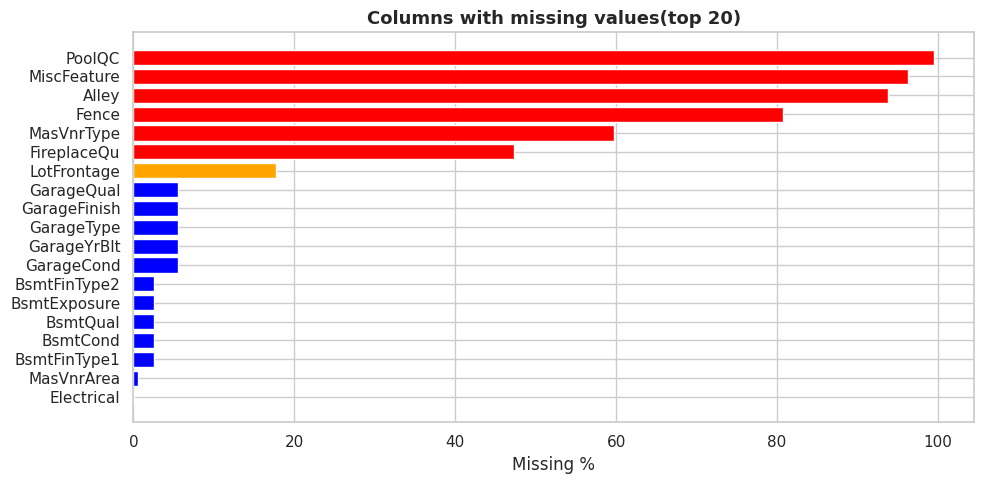

Columns >40% missing: 6
Columns >15% missing: 7


In [15]:
fig, ax = plt.subplots(figsize=(10,5))
bar_colors = ['red' if v>40 else 'orange' if v>15 else 'blue' for v in missing.values]
ax.barh(missing.index, missing.values, color=bar_colors)
ax.set_xlabel('Missing %')
ax.set_title('Columns with missing values(top 20)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Columns >40% missing: {(missing>40).sum()}')
print(f'Columns >15% missing: {(missing>15).sum()}')

In [16]:
numeric_features = [c for c in [
    "LotArea", "YearBuilt", "YearRemodAdd", "MasVnrArea",
    "BsmtFinSF1", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "GrLivArea", "FullBath", "HalfBath", "BedroomAbvGr",
    "TotRmsAbvGrd", "Fireplaces", "GarageCars", "GarageArea",
    "WoodDeckSF", "OpenPorchSF", "OverallQual", "OverallCond",
] if c in X.columns]

categorical_features = [c for c in [
    "MSZoning", "Street", "LotShape", "Neighborhood", "Condition1",
    "BldgType", "HouseStyle", "RoofStyle", "ExterQual", "ExterCond",
    "Foundation", "BsmtQual", "HeatingQC", "CentralAir",
    "KitchenQual", "GarageType", "SaleCondition",
] if c in X.columns]

In [17]:
corr_data = X[[c for c in X.columns if X[c].dtype in ["int64", "float64"]]].copy()
corr_data["SalePrice_log"] = y

top_corr_cols = (corr_data.corr()['SalePrice_log']
                 .abs()
                 .sort_values(ascending=False)
                 .head(12)
                 .index.tolist())

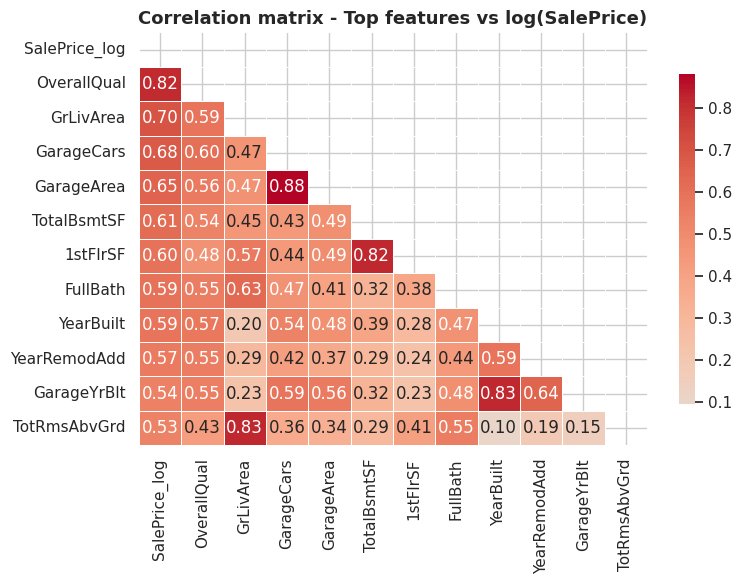

In [18]:
fig, ax = plt.subplots(figsize=(8,6))
mask = np.triu(np.ones_like(corr_data[top_corr_cols].corr(), dtype=bool))
sns.heatmap(
    corr_data[top_corr_cols].corr(), mask=mask, center=0,
    fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax,
    annot=True, cbar_kws={'shrink':0.8})
ax.set_title('Correlation matrix - Top features vs log(SalePrice)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
#preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('numeric features: ', len(numeric_features))
print('categorical features: ', len(categorical_features))

numeric features:  20
categorical features:  17


In [20]:
#model training and comparison
models = {
    'Ridge Regression': Ridge(alpha=10.0),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth= 4, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, random_state=42, subsample=0.8,
        colsample_bytree=0.8, verbosity=0
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

print(f'{'Model':<28} {"RMSE":>10} {'R2'}')
print('-'*60)

for name, model in models.items():
  pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
  neg_mse = cross_val_score(pipe, X, y, cv=kf, scoring='neg_mean_squared_error')
  r2 = cross_val_score(pipe, X, y, cv=kf, scoring='r2')
  rmse = np.sqrt(-neg_mse)
  results.append({
      'Model': name,
      'RMSE Mean': rmse.mean(),
      'RMSE Std': rmse.std(),
      'R2 Mean': r2.mean(),
      'R2 Std': r2.std(),
      })
  print(f'{name:<28}  {rmse.mean():.4f} ± {rmse.std():.4f}   {r2.mean():.4f} ± {r2.std():.4f}')
results_df = pd.DataFrame(results)

Model                              RMSE R2
------------------------------------------------------------
Ridge Regression              0.1486 ± 0.0406   0.8449 ± 0.1069
Gradient Boosting             0.1317 ± 0.0222   0.8857 ± 0.0471
XGBoost                       0.1291 ± 0.0195   0.8907 ± 0.0412


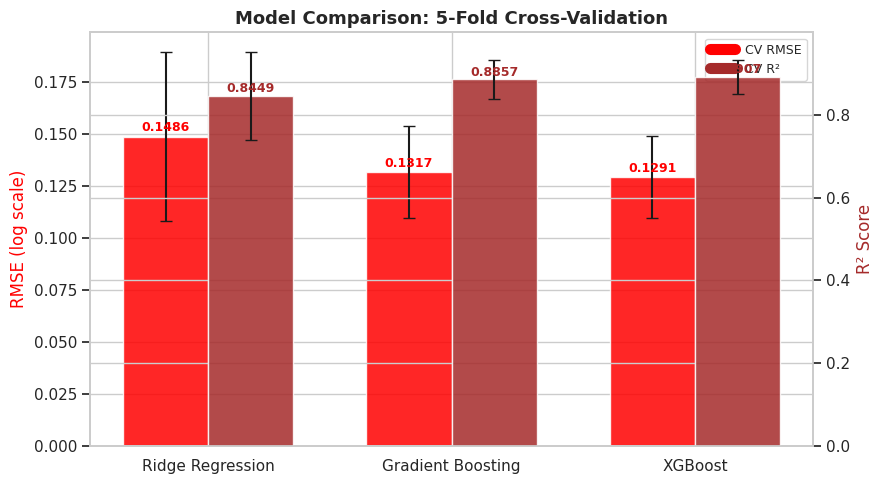


 Best model: XGBoost


In [21]:
#comparison bar chart
fig, ax1 = plt.subplots(figsize=(9,5))
ax2 = ax1.twinx()

x=np.arange(len(results_df))
w=0.35

bars1 = ax1.bar(x - w/2, results_df['RMSE Mean'], w, yerr=results_df['RMSE Std'], capsize=4, color='red', alpha=0.85, label='CV RMSE(log)')
bars2 = ax2.bar(x + w/2, results_df['R2 Mean'], w, yerr=results_df['R2 Std'], capsize=4, color='brown', alpha=0.85, label='CV R2')

ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], fontsize=11)
ax1.set_ylabel('RMSE (log scale)', color='red')
ax2.set_ylabel('R² Score',         color='brown')
ax1.set_title('Model Comparison: 5-Fold Cross-Validation', fontsize=13, fontweight='bold')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom',
             color='red', fontsize=9, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom',
             color='brown', fontsize=9, fontweight='bold')

lines = [plt.Line2D([0],[0], color='red', lw=8),
         plt.Line2D([0],[0], color='brown', lw=8)]
ax1.legend(lines, ['CV RMSE', 'CV R²'], loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

best_name = results_df.loc[results_df['RMSE Mean'].idxmin(), 'Model']
print(f'\n Best model: {best_name}')

In [22]:
#feature importance
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.compose import ColumnTransformer as CT
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [23]:
xgb_pipe = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='Missing')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
                                                                     categorical_features),
    ])),
    ('model', XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0,
    )),
])

xgb_pipe.fit(X, y)

ohe           = xgb_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
importances   = xgb_pipe.named_steps['model'].feature_importances_

feat_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
             .sort_values('Importance', ascending=True)
             .tail(15))

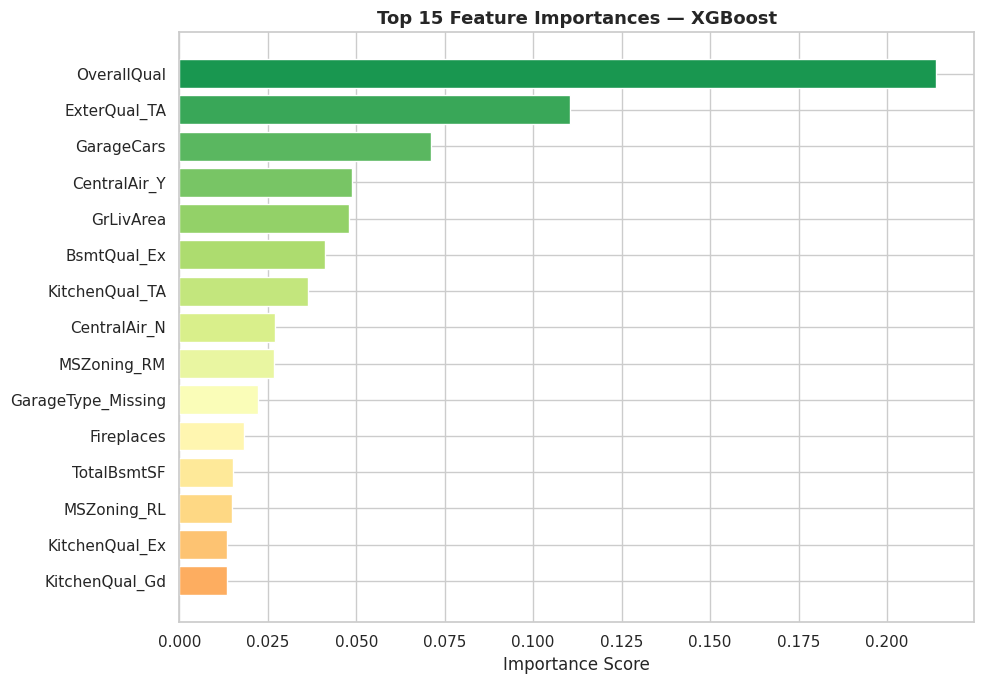

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_df)))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=bar_colors)
ax.set_title('Top 15 Feature Importances — XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

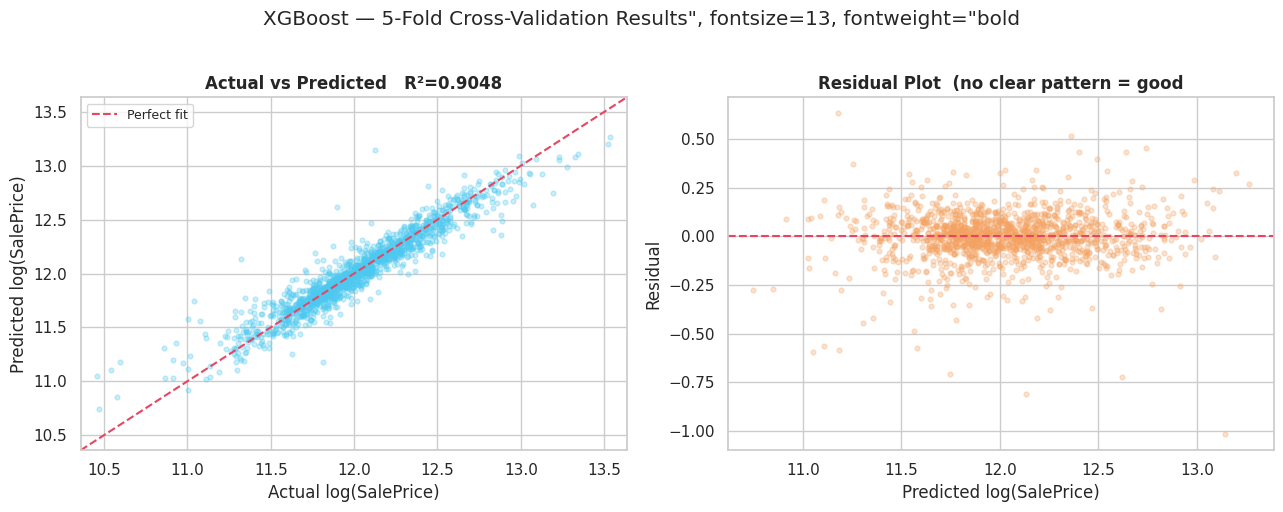


 Final Results (XGBoost, 5-fold CV) 
  R²   : 0.9048
  RMSE : 0.1232  (log scale)
  Approx. price error: ±-86.9%


In [25]:
#actual vs predicted + the residuals
y_pred    = cross_val_predict(xgb_pipe, X, y, cv=5)
r2_final  = r2_score(y, y_pred)
rmse_final = np.sqrt(np.mean((y - y_pred) ** 2))
residuals  = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
#actual vs predicted
axes[0].scatter(y, y_pred, alpha=0.3, s=12, color='#4cc9f0')
lims = [min(y.min(), y_pred.min()) - 0.1,
        max(y.max(), y_pred.max()) + 0.1]
axes[0].plot(lims, lims, '--', color='#e94560', lw=1.5, label='Perfect fit')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title(f'Actual vs Predicted   R²={r2_final:.4f}', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

#residuals
axes[1].scatter(y_pred, residuals, alpha=0.3, s=12, color='#f4a261')
axes[1].axhline(0, color='#e94560', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted log(SalePrice)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot  (no clear pattern = good',
                  fontsize=12, fontweight="bold")

plt.suptitle('XGBoost — 5-Fold Cross-Validation Results", fontsize=13, fontweight="bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Final Results (XGBoost, 5-fold CV) ')
print(f'  R²   : {r2_final:.4f}')
print(f'  RMSE : {rmse_final:.4f}  (log scale)')
print(f'  Approx. price error: ±{(np.expm1(rmse_final)-1)*100:.1f}%')